# Tester_branch에서 성능 확인 진행

In [46]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''
# Bunch 객체를 DataFrame으로 변환
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
wine_df['target'] = wine.target  # target 추가

# feature와 target 분리
X = wine_df.drop('target', axis=1)
y = wine_df['target']
# train/test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

# DT 모델링 성능

Best Hyper-parameter: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.9444444444444444


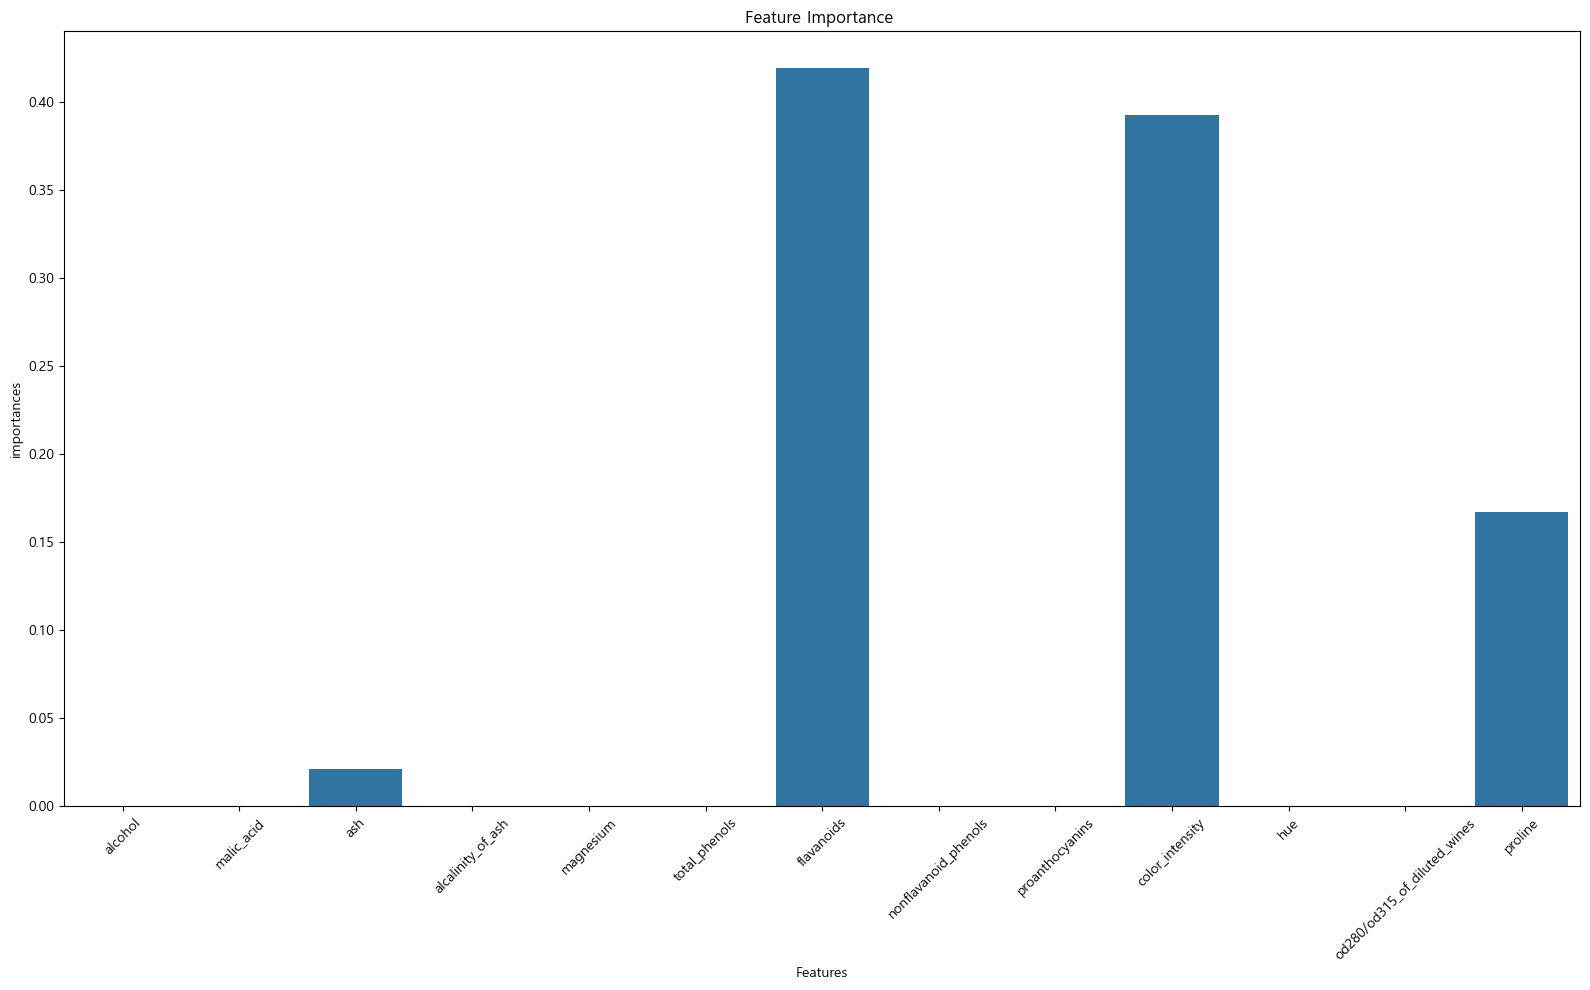

In [47]:
''' 코드를 작성해주세요 '''
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# 하이퍼파라미터 후보
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2,3,4,5],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1, 2, 4]
}
#모델 정의 및 GridSearchCV 설정
DT =  DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(DT, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

#최적 모델로 예측 및 평가
dt_best_model = grid_search.best_estimator_
dt_y_pred = dt_best_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_y_pred)
print("Best Hyper-parameter:", grid_search.best_params_)
print("Best Score:", dt_accuracy)

#Feature Importance 시각화
importances = pd.Series(dt_best_model.feature_importances_, index=X.columns)


plt.figure(figsize=(16, 10))
sns.barplot(x=importances.index, y=importances)
plt.title("Feature Importance ")
plt.xlabel("Features")
plt.ylabel("importances")
plt.xticks(rotation =45)
plt.tight_layout()
plt.show()

# XGB 모델링 성능

Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best accuracy: 0.9722222222222222


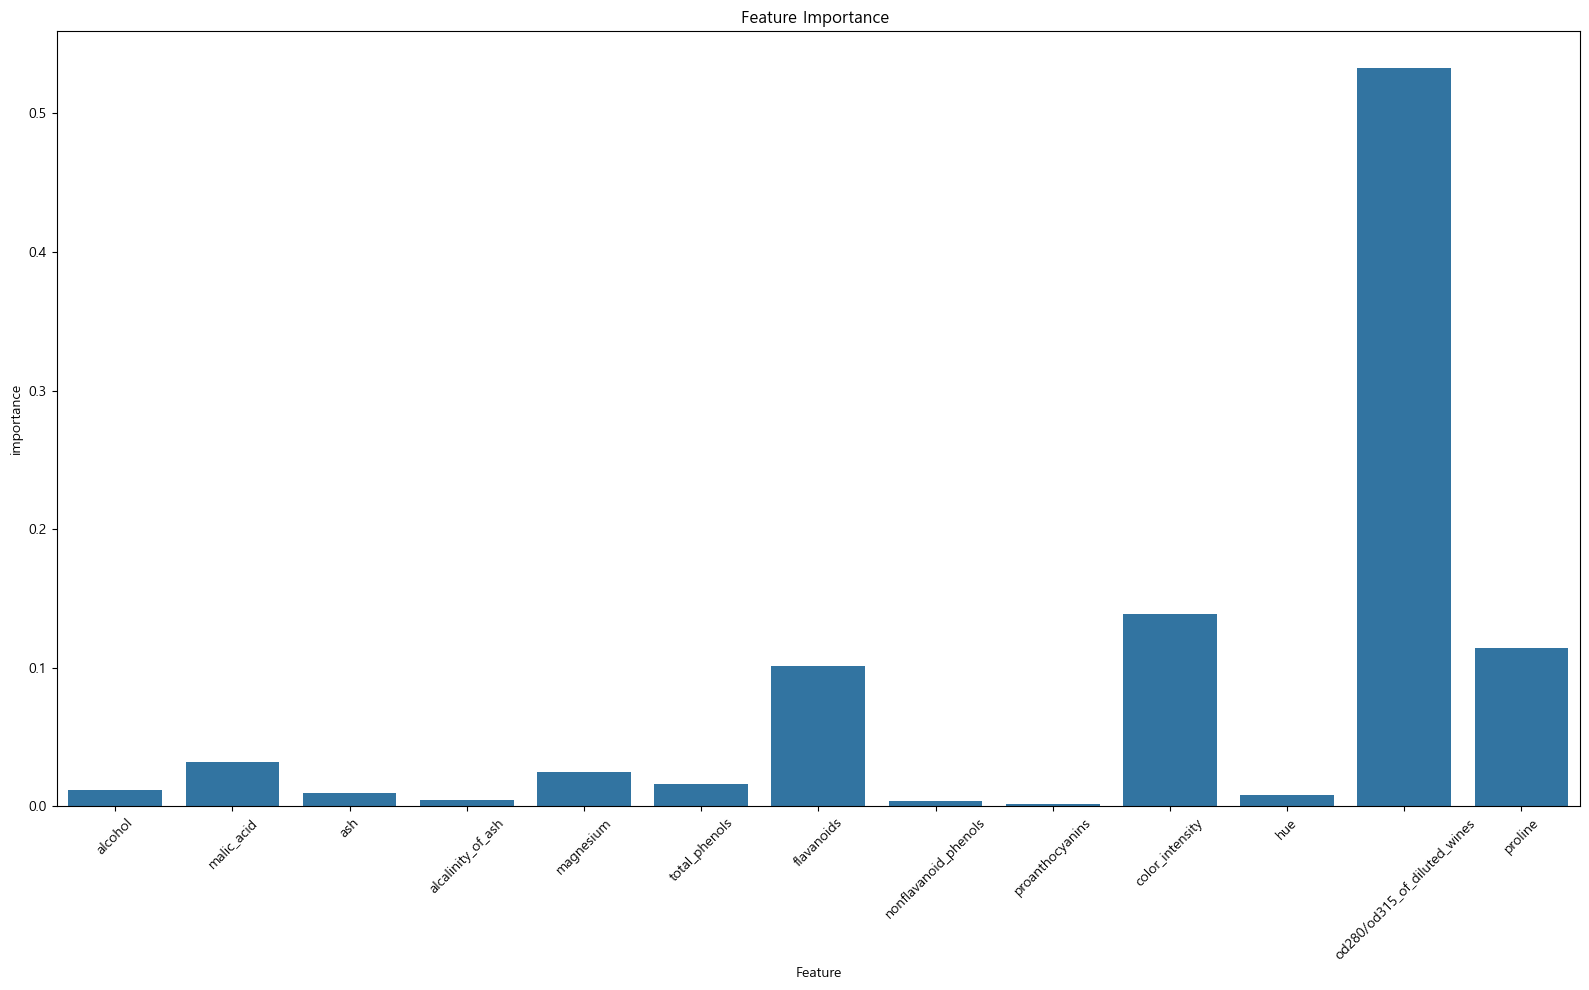

In [48]:
''' 코드를 작성해주세요 '''
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns
# XGBClassifier모델 생성성
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 하이퍼파라미터 후보 설정
param_grid = {
    'max_depth': [3, 5, 7, 9, 15],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200, 300]
}
# GridSearchCV 설정 (cv=5, scoring 기준은 Accuracy)
grid_search = GridSearchCV(estimator=xgb_model, 
                           param_grid=param_grid, 
                           scoring='accuracy', 
                           cv=5)
#모델 학습 (GridSearch)
grid_search.fit(X_train, y_train)

# 최적 모델로 테스트셋 예측 및 정확도 평가
xgb_best_model = grid_search.best_estimator_
xgb_y_pred = xgb_best_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", xgb_accuracy)
#Feature Importance 시각화
importances = pd.Series(xgb_best_model.feature_importances_, index=X.columns)

plt.figure(figsize=(16, 10))
sns.barplot(x=importances.index, y=importances)
plt.title("Feature Importance ")
plt.xlabel("Feature")
plt.ylabel("importance")
plt.xticks(rotation =45)
plt.tight_layout()
plt.show()

# 성능 비교 시각화

=============== DT 성능 확인 ===============
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

=============== XGB 성능 확인 ===============
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



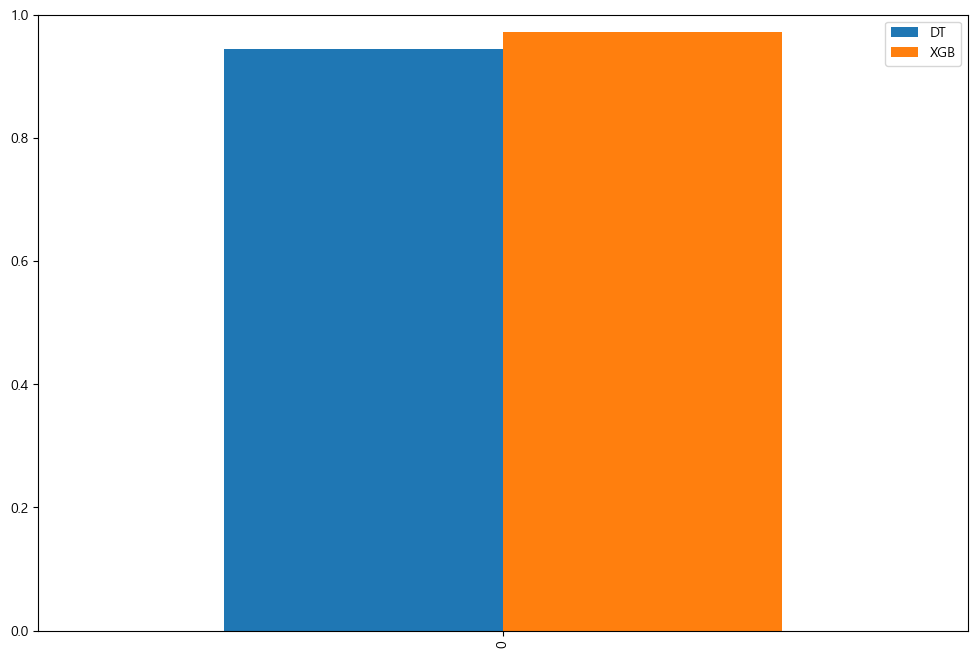

In [51]:
''' 코드를 작성해주세요 '''
from sklearn.metrics import  classification_report
print("=============== DT 성능 확인 ===============")
print(f"DT accuracy : {dt_accuracy}")
print(classification_report(y_test, dt_y_pred))

print("=============== XGB 성능 확인 ===============")
print(f"XGB accuracy : {xgb_accuracy}")
print(classification_report(y_test, xgb_y_pred))

#accuracy 성능 비교 시각화 
import matplotlib.pyplot as plt
plt.rc('font', family = 'Malgun Gothic')

#fig, ax=plt.figure(figsize=(12, 8))
fig, ax = plt.subplots(figsize=(12, 8))
# 막대 폭 설정
width = 0.3
# 첫 번째 막대: x=0.2 ~ 0.5
plt.bar(0.2, dt_accuracy, width=width, color='#1f77b4', label='DT', align='edge')

# 두 번째 막대: x=0.5 ~ 0.8
plt.bar(0.5, xgb_accuracy, width=width, color='#ff7f0e', label='XGB', align='edge')

# 세로축 범위
plt.ylim([0, 1])
# 가로축 범위
plt.xlim([0, 1])
#x축 가운데에 라벨 표시
ax.set_xticks([0.5])
ax.set_xticklabels(["0"])
plt.xticks(rotation=90)
# 범례 표시 (오른쪽 위)
plt.legend(loc='upper right')

plt.show()